# 1 — Imports & Setup

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

# Auto-detect project root
root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ResNet50 import ResNet50

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Device  : cuda
PyTorch : 2.11.0+cu130


# 2 — Hyperparameters (Optimised)

In [2]:
EPOCHS       = 100
BATCH_SIZE   = 16
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4
NUM_CLASSES  = 28

print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"LR          : {LR}")
print(f"Dropout     : {DROPOUT}")


Epochs      : 100
Batch size  : 16
LR          : 0.0001
Dropout     : 0.4


# 3 — Data Pipeline (Optimised Augmentation)
Uses the ConvNeXt‑style optimal augmentation:
PadToSquare
RandomResizedCrop (stronger scale range)
flips
rotations
ColorJitter
GaussianBlur
RandomErasing
TrivialAugmentWide
WaRP‑C mean/std
WeightedRandomSampler
minority augmentation

In [3]:
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/WaRP-C",
    processed_root = root / "Dataset/processed",
    stats_file     = root / "Dataset/dataset_stats.json",
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

train_loader, test_loader = pp.get_loaders(model_type="convnext")  # stronger aug

CLASS_NAMES = sorted(
    d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir()
)

print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

[get_loaders] model='convnext'
  sampler=True  minority_aug=True  mixup=True  pipeline='transformer'
  train=547 batches  test=97 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 547
Test  batches : 97


# 4 — Loss Function

In [4]:
class_weights = pp.get_class_weights(device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")

Loss: CrossEntropyLoss + class weights


# 5 — Model (ResNet‑50 Optimised)

In [5]:
model = ResNet50(
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max = EPOCHS,
    eta_min = 1e-7
)

scaler = GradScaler(enabled=(DEVICE == "cuda"))

# Sanity check
with torch.no_grad():
    out = model(torch.zeros(2, 3, 384, 384).to(DEVICE))
print("Output shape:", out.shape)


Output shape: torch.Size([2, 28])


# 6 — Training Loop

In [7]:
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

print(f"Starting {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):

    model.train()
    ep_loss = correct = total = 0
    t0 = time.time()

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()

        with autocast(device_type="cuda", enabled=(DEVICE == "cuda")):
            logits = model(imgs)
            loss   = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    scheduler.step()

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    test_acc = correct / total * 100

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), root / "Models/weights/resnet50_optimal.pth")
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
          f"test={test_acc:.2f}% | best={best_acc:.2f}% | "
          f"{time.time()-t0:.1f}s{flag}")

Starting 100 epochs...

Epoch   1/100 | loss=2.8369 | train=6.98% | test=3.68% | best=3.68% | 15.0s ← best
Epoch   2/100 | loss=2.3141 | train=16.20% | test=10.57% | best=10.57% | 8.0s ← best
Epoch   3/100 | loss=1.9902 | train=23.90% | test=13.60% | best=13.60% | 8.0s ← best
Epoch   4/100 | loss=1.7979 | train=28.69% | test=15.09% | best=15.09% | 8.0s ← best
Epoch   5/100 | loss=1.7416 | train=31.33% | test=19.86% | best=19.86% | 8.0s ← best
Epoch   6/100 | loss=1.5909 | train=34.32% | test=23.47% | best=23.47% | 8.0s ← best
Epoch   7/100 | loss=1.5225 | train=36.54% | test=23.98% | best=23.98% | 8.0s ← best
Epoch   8/100 | loss=1.4767 | train=37.85% | test=23.53% | best=23.98% | 8.0s
Epoch   9/100 | loss=1.4057 | train=39.58% | test=23.98% | best=23.98% | 7.9s
Epoch  10/100 | loss=1.4258 | train=40.07% | test=27.85% | best=27.85% | 8.0s ← best
Epoch  11/100 | loss=1.3832 | train=41.35% | test=29.27% | best=29.27% | 8.0s ← best
Epoch  12/100 | loss=1.3169 | train=43.01% | test=30.69% 

# 7 — Training Curves

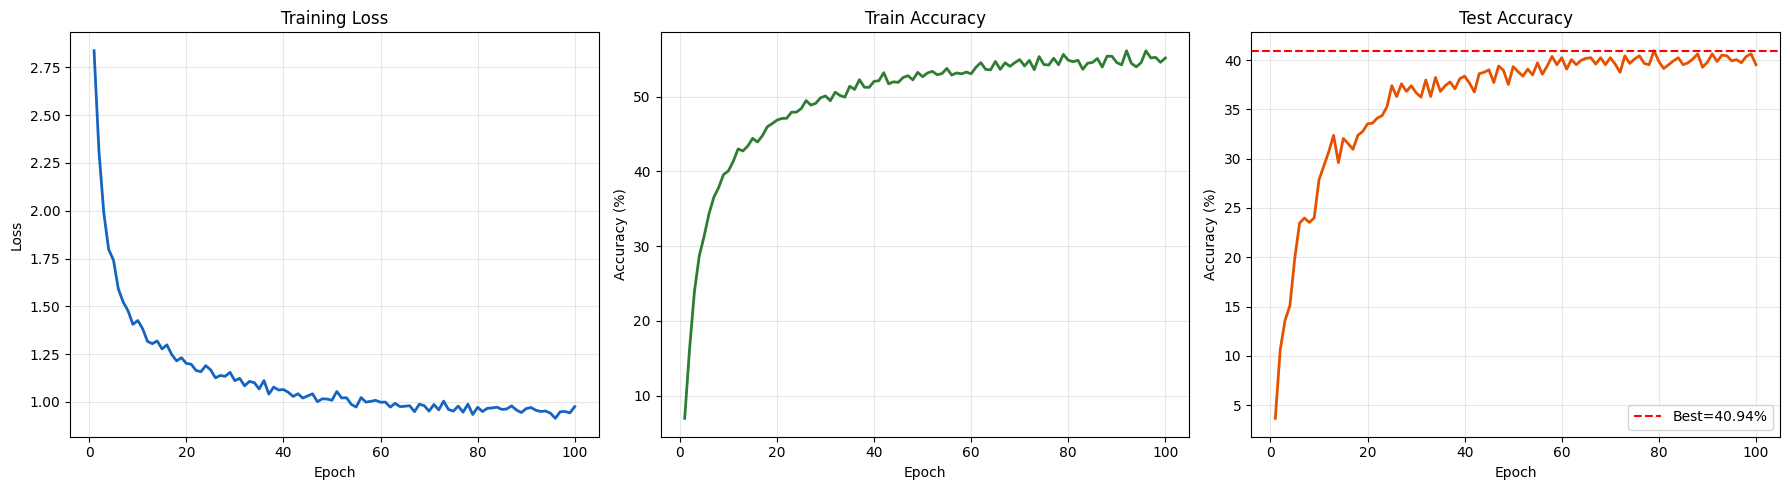

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(best_acc, color="red", ls="--", label=f"Best={best_acc:.2f}%")
axes[2].set(title="Test Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 8 — Evaluation (Final Metrics)

In [9]:
model.load_state_dict(torch.load(root / "Models/weights/resnet50_optimal.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

acc  = (y_pred == y_true).mean() * 100
f1   = f1_score(y_true, y_pred, average="macro") * 100
w_f1 = f1_score(y_true, y_pred, average="weighted") * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100

print("="*50)
print("  ResNet‑50 Optimised — Final Metrics")
print("="*50)
print(f"  Accuracy      : {acc:.2f}%")
print(f"  Macro F1      : {f1:.2f}%")
print(f"  Weighted F1   : {w_f1:.2f}%")
print(f"  Precision     : {prec:.2f}%")
print(f"  Recall        : {rec:.2f}%")
print("="*50)


  ResNet‑50 Optimised — Final Metrics
  Accuracy      : 40.94%
  Macro F1      : 43.00%
  Weighted F1   : 38.69%
  Precision     : 47.45%
  Recall        : 52.49%


# 9 — Confusion Matrix

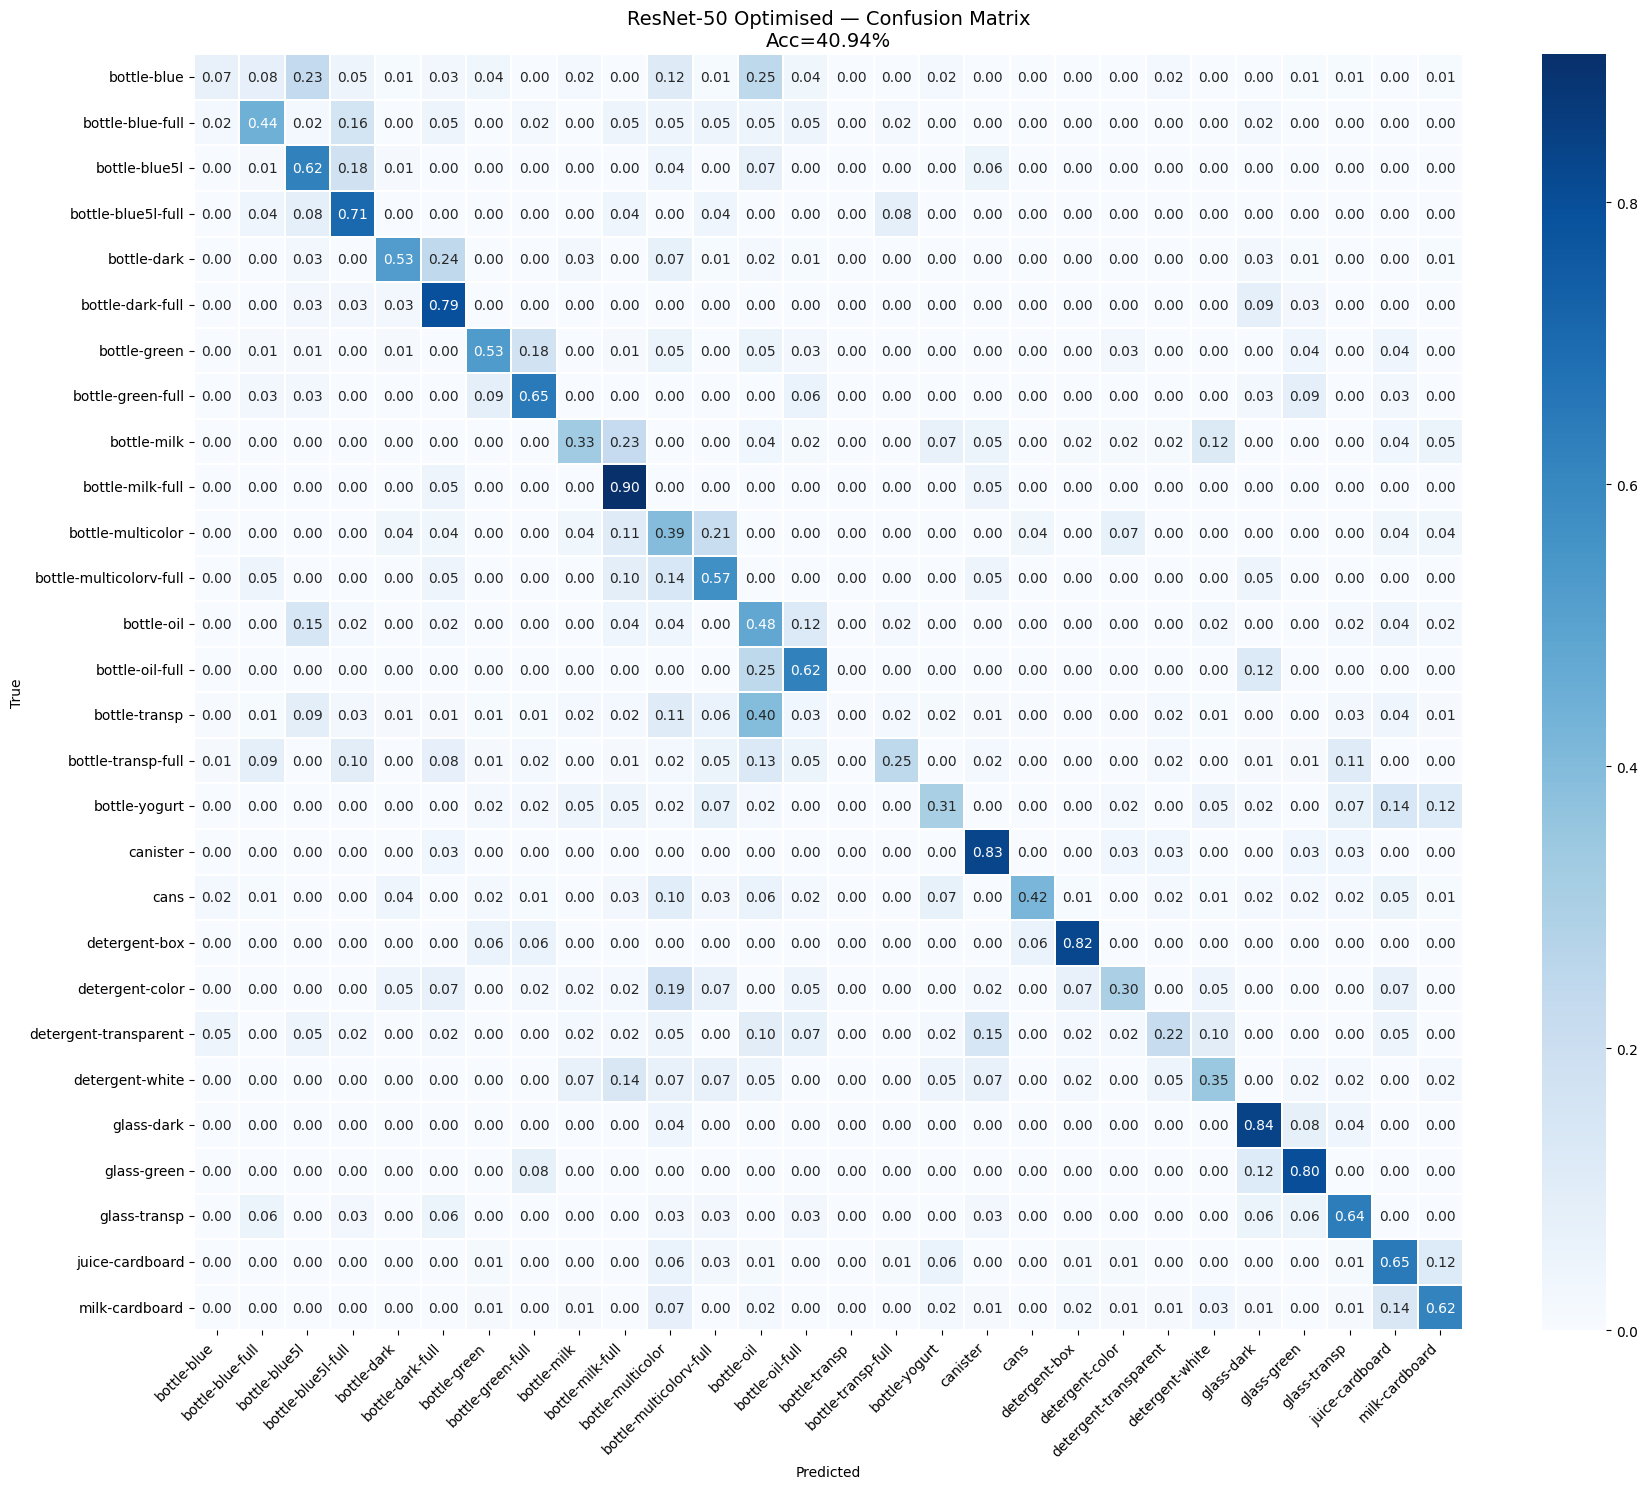

In [10]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(f"ResNet‑50 Optimised — Confusion Matrix\nAcc={acc:.2f}%", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 10 — Summary

In [11]:
print("="*60)
print("  ResNet‑50 Optimised — Summary")
print("="*60)
print(f"  Pretrained       : ImageNet‑1K")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  LR               : {LR}")
print(f"  Dropout          : {DROPOUT}")
print(f"  Scheduler        : CosineAnnealingLR")
print(f"  Best test acc    : {best_acc:.2f}%")
print(f"  Final accuracy   : {acc:.2f}%")
print(f"  Macro F1         : {f1:.2f}%")
print(f"  Weighted F1      : {w_f1:.2f}%")
print("="*60)


  ResNet‑50 Optimised — Summary
  Pretrained       : ImageNet‑1K
  Epochs           : 100
  Batch size       : 16
  LR               : 0.0001
  Dropout          : 0.4
  Scheduler        : CosineAnnealingLR
  Best test acc    : 40.94%
  Final accuracy   : 40.94%
  Macro F1         : 43.00%
  Weighted F1      : 38.69%
